# Pendulum Parameter Identification: Global vs Local Optima
This notebook converts the Julia-based identification workflow into Python. We simulate a pendulum, identify the length parameter, visualize the cost landscape, and compare gradient-based optimization with a global particle swarm heuristic.

In [2]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import time

np.random.seed(14588)

We investigate the pendulum model:

\[ \frac{d}{dt} x(t) = \begin{bmatrix} x_2(t) \\ -\frac{g}{L} \sin(x_1(t)) - \frac{b}{m} x_2(t) \end{bmatrix} \]

with states $x = [\theta, \dot{\theta}]^T$. Here we identify the pendulum length $L$ while assuming a known small friction coefficient.

In [3]:
# Model parameters defined as constants
g = 9.81  # gravity constant
L = 1.0   # true pendulum length
b = 0.025 # damping coefficient
m = 0.5   # mass of pendulum

x0 = [0.0, np.pi / 2]  # initial condition
tspan = (0.0, 4.0)
t_eval = np.arange(tspan[0], tspan[1] + 1e-8, 0.05)

Generate noisy ground truth measurements from the true pendulum dynamics.

In [4]:
def simple_pendulum(t, x):
    theta, omega = x
    return [omega, -(g / L) * np.sin(theta) - (b / m) * omega]

sol = solve_ivp(simple_pendulum, tspan, x0, t_eval=t_eval, vectorized=False)

t = sol.t
x = sol.y
sigma = 0.05
y = x + sigma * np.random.randn(*x.shape)

Define the training model and cost function for estimating the pendulum length.

In [5]:
def simple_pendulum_train(t, x, length):
    theta, omega = x
    return [omega, -(g / length) * np.sin(theta) - (b / m) * omega]


def simulate_with_length(length):
    sol = solve_ivp(lambda tt, xx: simple_pendulum_train(tt, xx, length), tspan, x0, t_eval=t_eval, vectorized=False)
    return sol.y


def cost_function(length_vector):
    length = float(length_vector[0])
    x_pred = simulate_with_length(length)
    return np.sum((y - x_pred) ** 2)

Visualize the scalar cost function over a range of candidate lengths.

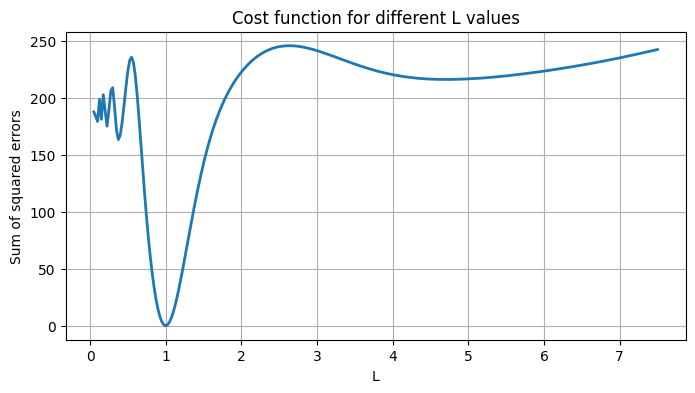

In [6]:
L_vec = np.linspace(0.05, 7.5, 300)
cost_vec = np.array([cost_function([L_val]) for L_val in L_vec])

plt.figure(figsize=(8, 4))
plt.plot(L_vec, cost_vec, lw=2)
plt.xlabel('L')
plt.ylabel('Sum of squared errors')
plt.title('Cost function for different L values')
plt.grid(True)
plt.show()

The cost landscape has multiple local minima. A gradient-based optimizer can converge to a poor local solution depending on the initial guess.

In [7]:
initial_guess = [0.5]
res = minimize(cost_function, initial_guess, method='BFGS', options={'disp': True})
res

Optimization terminated successfully.
         Current function value: 163.283024
         Iterations: 6
         Function evaluations: 26
         Gradient evaluations: 13


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 163.28302443320138
        x: [ 3.773e-01]
      nit: 6
      jac: [-9.537e-06]
 hess_inv: [[ 5.169e-05]]
     nfev: 26
     njev: 13

Identified length: 0.3772945967931991


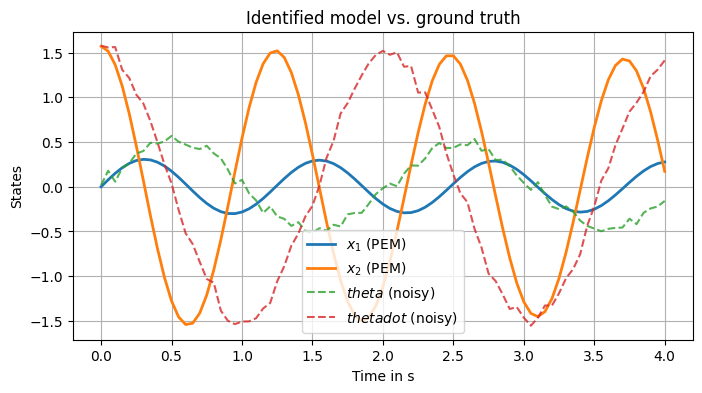

In [12]:
# Visualize the identified model from the local optimizer
identified_length = float(res.x[0])
print('Identified length:', identified_length)

x_pred_local = simulate_with_length(identified_length)

plt.figure(figsize=(8, 4))
plt.plot(t, x_pred_local.T[:, 0], label=r'$x_1$ (PEM)', lw=2)
plt.plot(t, x_pred_local.T[:, 1], label=r'$x_2$ (PEM)', lw=2)
plt.plot(t, y.T[:, 0], '--', label=r'$theta$ (noisy)', alpha=0.8)
plt.plot(t, y.T[:, 1], '--', label=r'$thetadot$ (noisy)', alpha=0.8)
plt.xlabel('Time in s')
plt.ylabel('States')
plt.title('Identified model vs. ground truth')
plt.legend()
plt.grid(True)
plt.show()

To overcome the local optimum issue, we use a global heuristic: particle swarm optimization (PSO).

In [13]:
def particle_swarm_optimization(func, bounds, n_particles=10, iterations=50, inertia=0.7, cognitive=1.5, social=1.5):
    lower, upper = np.array(bounds[0]), np.array(bounds[1])
    dim = lower.size
    x = np.random.uniform(lower, upper, size=(n_particles, dim))
    v = np.zeros_like(x)

    pbest = x.copy()
    pbest_scores = np.array([func(xi) for xi in x])
    best_idx = np.argmin(pbest_scores)
    gbest = pbest[best_idx].copy()
    gbest_score = pbest_scores[best_idx]

    for _ in range(iterations):
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)
        v = inertia * v + cognitive * r1 * (pbest - x) + social * r2 * (gbest - x)
        x = x + v
        x = np.clip(x, lower, upper)

        scores = np.array([func(xi) for xi in x])
        improved = scores < pbest_scores
        pbest[improved] = x[improved]
        pbest_scores[improved] = scores[improved]

        idx = np.argmin(pbest_scores)
        if pbest_scores[idx] < gbest_score:
            gbest = pbest[idx].copy()
            gbest_score = pbest_scores[idx]

    return gbest, gbest_score

bounds = ([0.01], [10.0])
res_pso, pso_cost = particle_swarm_optimization(cost_function, bounds, n_particles=10, iterations=50)
print('Found parameter:', res_pso)
print('Ground truth:', L)

Found parameter: [0.99925897]
Ground truth: 1.0


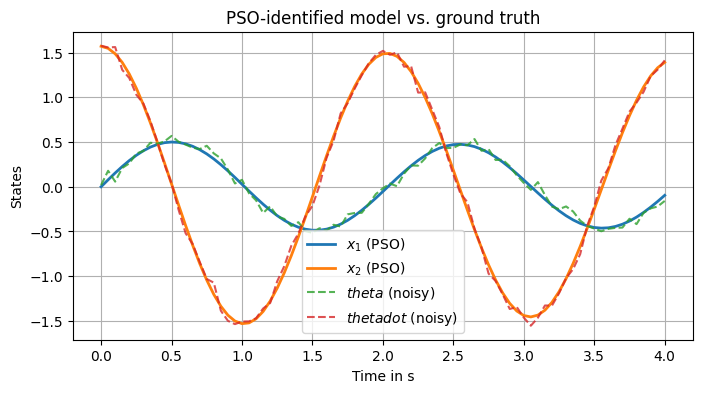

In [15]:
identified_length_pso = float(res_pso[0])
x_pred_pso = simulate_with_length(identified_length_pso)

plt.figure(figsize=(8, 4))
plt.plot(t, x_pred_pso.T[:, 0], label=r'$x_1$ (PSO)', lw=2)
plt.plot(t, x_pred_pso.T[:, 1], label=r'$x_2$ (PSO)', lw=2)
plt.plot(t, y.T[:, 0], '--', label=r'$theta$ (noisy)', alpha=0.8)
plt.plot(t, y.T[:, 1], '--', label=r'$thetadot$ (noisy)', alpha=0.8)
plt.xlabel('Time in s')
plt.ylabel('States')
plt.title('PSO-identified model vs. ground truth')
plt.legend()
plt.grid(True)
plt.show()

The PSO-based global search often finds the true parameter better than a single gradient-based run, but it requires more function evaluations and computational effort.

In [16]:
start_time = time.perf_counter()
res_pso_timed, _ = particle_swarm_optimization(cost_function, bounds, n_particles=10, iterations=50)
end_time = time.perf_counter()
print(f'PSO runtime: {end_time - start_time:.4f} seconds')

PSO runtime: 1.2249 seconds
